In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

patients = pd.read_csv("patients.csv")
conditions = pd.read_csv("conditions.csv")

Saving patients.csv to patients (1).csv
Saving conditions.csv to conditions.csv


In [ ]:
print(patients.columns)
print(conditions.columns)
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])

# Use a reference year
reference_year = 2020

patients['AGE'] = reference_year - patients['BIRTHDATE'].dt.year

patients['MALE'] = patients['GENDER'].apply(lambda x: 1 if x == 'M' else 0)

conditions_clean = conditions[['PATIENT', 'CODE']]
conditions_clean = conditions_clean.drop_duplicates()

conditions_grouped = conditions_clean.groupby('PATIENT')['CODE'].apply(list).reset_index()

data = patients.merge(conditions_grouped, left_on='Id', right_on='PATIENT', how='left')

data['CODE'] = data['CODE'].apply(lambda x: x if isinstance(x, list) else [])

print(data.head())
print(data['AGE'].describe())
print(data['CODE'].head())



Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY',
       'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP',
       'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'AGE',
       'MALE'],
      dtype='object')
Index(['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION'], dtype='object')
                                     Id  BIRTHDATE DEATHDATE          SSN  \
0  b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85 2019-02-17       NaN  999-65-3251   
1  c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8 2005-07-04       NaN  999-49-3323   
2  339144f8-50e1-633e-a013-f361391c4cff 1998-05-11       NaN  999-10-8743   
3  d488232e-bf14-4bed-08c0-a82f34b6a197 2003-01-28       NaN  999-56-6057   
4  217f95a3-4e10-bd5d-fb67-0cfb5e8ba075 1993-12-23       NaN  999-91-4320   

     DRIVERS    PASSPORT PREFIX       FIRST            LAST SUFFIX  ...  \
0        NaN         NaN    NaN

In [ ]:
data = data[data['AGE'] >= 0]


In [ ]:
conditions_desc = conditions[['PATIENT', 'DESCRIPTION']].drop_duplicates()
conditions_grouped_desc = conditions_desc.groupby('PATIENT')['DESCRIPTION'].apply(list).reset_index()

data = data.merge(conditions_grouped_desc, left_on='Id', right_on='PATIENT', how='left')

data['DESCRIPTION'] = data['DESCRIPTION'].apply(lambda x: x if isinstance(x, list) else [])


def has_condition(desc_list, keywords):
    return int(any(any(keyword.lower() in desc.lower() for keyword in keywords) for desc in desc_list))

In [ ]:
data['HCC_DIABETES'] = data['DESCRIPTION'].apply(lambda x: has_condition(x, ['diabetes']))
data['HCC_CARDIO'] = data['DESCRIPTION'].apply(lambda x: has_condition(x, ['heart', 'cardiac', 'hypertension']))
data['HCC_RESP'] = data['DESCRIPTION'].apply(lambda x: has_condition(x, ['asthma', 'copd', 'respiratory']))
data['HCC_CANCER'] = data['DESCRIPTION'].apply(lambda x: has_condition(x, ['cancer', 'tumor']))
data['HCC_RENAL'] = data['DESCRIPTION'].apply(lambda x: has_condition(x, ['kidney', 'renal']))

In [ ]:
print(data[['HCC_DIABETES', 'HCC_CARDIO', 'HCC_RESP', 'HCC_CANCER', 'HCC_RENAL']].sum())

HCC_DIABETES    364
HCC_CARDIO      392
HCC_RESP         44
HCC_CANCER       27
HCC_RENAL        32
dtype: int64


In [ ]:
data['RISK_SCORE'] = (
    0.3
    + 0.02 * data['AGE']
    + 0.1 * data['MALE']
    + 0.5 * data['HCC_DIABETES']
    + 0.7 * data['HCC_CARDIO']
    + 0.4 * data['HCC_RESP']
    + 0.8 * data['HCC_CANCER']
    + 0.6 * data['HCC_RENAL']
)

In [ ]:
print(data['RISK_SCORE'].describe())

count    1153.000000
mean        1.673929
std         0.911145
min         0.300000
25%         0.880000
50%         1.600000
75%         2.280000
max         4.780000
Name: RISK_SCORE, dtype: float64


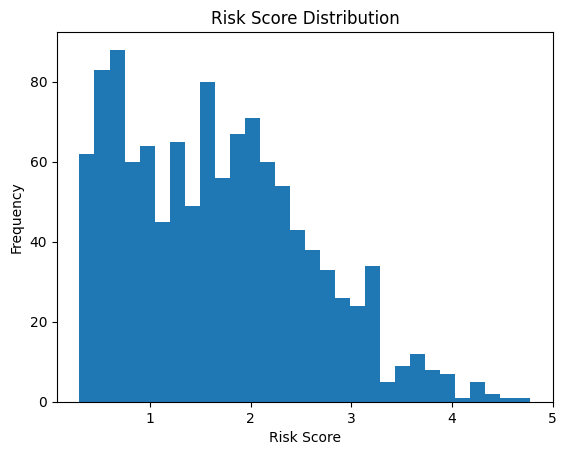

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data['RISK_SCORE'], bins=30)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(data[['AGE', 'RISK_SCORE']].head())

   AGE  RISK_SCORE
0    1        0.42
1   15        0.60
2   22        1.54
3   17        0.64
4   27        0.94


In [ ]:
features_basic = ['AGE', 'MALE']

features_full = [
    'AGE', 'MALE',
    'HCC_DIABETES', 'HCC_CARDIO', 'HCC_RESP',
    'HCC_CANCER', 'HCC_RENAL',
    'RISK_SCORE'
]

X_basic = data[features_basic]
X_full = data[features_full]

y = data['HEALTHCARE_EXPENSES']

In [ ]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, y_train, y_test = train_test_split(X_basic, y, test_size=0.2, random_state=42)
Xf_train, Xf_test, _, _ = train_test_split(X_full, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model_basic = LinearRegression()
model_full = LinearRegression()

model_basic.fit(Xb_train, y_train)
model_full.fit(Xf_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predictions
y_pred_basic = model_basic.predict(Xb_test)
y_pred_full = model_full.predict(Xf_test)

# Metrics
print("Basic Model R2:", r2_score(y_test, y_pred_basic))
print("Full Model R2:", r2_score(y_test, y_pred_full))

print("Basic MAE:", mean_absolute_error(y_test, y_pred_basic))
print("Full MAE:", mean_absolute_error(y_test, y_pred_full))

Basic Model R2: 0.43527799544300605
Full Model R2: 0.4816042273930383
Basic MAE: 402317.204513814
Full MAE: 407131.1063069854


In [ ]:
y = data['HEALTHCARE_EXPENSES']

import numpy as np

y_log = np.log1p(data['HEALTHCARE_EXPENSES'])

# Split again
Xb_train, Xb_test, y_train, y_test = train_test_split(X_basic, y_log, test_size=0.2, random_state=42)
Xf_train, Xf_test, _, _ = train_test_split(X_full, y_log, test_size=0.2, random_state=42)

# Train
model_basic.fit(Xb_train, y_train)
model_full.fit(Xf_train, y_train)

# Predict
y_pred_basic = model_basic.predict(Xb_test)
y_pred_full = model_full.predict(Xf_test)

print("Basic R2:", r2_score(y_test, y_pred_basic))
print("Full R2:", r2_score(y_test, y_pred_full))

print("Basic MAE:", mean_absolute_error(y_test, y_pred_basic))
print("Full MAE:", mean_absolute_error(y_test, y_pred_full))




Basic R2: 0.4852916343385545
Full R2: 0.498138903444161
Basic MAE: 0.6696112857064047
Full MAE: 0.6531275966223256


In [ ]:
import pandas as pd

importance = pd.Series(model_full.coef_, index=X_full.columns)
print(importance.sort_values(ascending=False))

HCC_RESP        0.168838
HCC_DIABETES    0.134602
HCC_CARDIO      0.085771
RISK_SCORE      0.078635
HCC_CANCER      0.032587
AGE             0.023983
HCC_RENAL      -0.175031
MALE           -0.377714
dtype: float64
